In [12]:
pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install nbformat


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
gdp = pd.read_csv('/Users/maanaskauntia/Desktop/GDP_vs_Life_Satisfaction/2024_WB_GDP_PerCapita_PPP.csv') # variable for GDP Per Capita PPP
ladder_score = pd.read_csv('/Users/maanaskauntia/Desktop/GDP_vs_Life_Satisfaction/WHR2024_Data.csv') # variable for life satisfaction ladder scores

In [17]:
gdp.head(10)

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,UZB,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VUT,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VEN,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VNM,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
5,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
6,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
7,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
8,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFE,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
9,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFW,WB_WDI_NY_GDP_PCAP_PP_CD,_T,_T,_T,PPP,...,Not Applicable,Not Applicable,Not Applicable,Currency,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [18]:
ladder_score.head()

,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [19]:
gdp_2024 = gdp[gdp['TIME_PERIOD']==2024] # Filtering for data of the year 2024
gdp_2024 = gdp_2024[['REF_AREA_LABEL', 'OBS_VALUE']] # Keeping only the Country Name and GDP value in the dataset
gdp_2024.head(25)

,REF_AREA_LABEL,OBS_VALUE
4768,Eastern & Southern Africa,4635.788224
4769,Western & Central Africa,6815.990961
4770,Arab World,18870.314810
4771,Caribbean small states,38624.060540
4772,Central Europe and the Baltics,50487.330480
4773,Early-demographic dividend,13995.405560
4774,East Asia & Pacific,27285.211230
4775,East Asia & Pacific (excluding high income),23248.025180
4776,East Asia & Pacific (IDA & IBRD),23509.724170
4777,Euro area,66097.020720


In [20]:
ladder_score['Country name'].unique()

<StringArray>
[         'Finland',          'Denmark',          'Iceland',
           'Sweden',           'Israel',      'Netherlands',
           'Norway',       'Luxembourg',      'Switzerland',
        'Australia',
 ...
           'Zambia',         'Eswatini',           'Malawi',
         'Botswana',         'Zimbabwe', 'Congo (Kinshasa)',
     'Sierra Leone',          'Lesotho',          'Lebanon',
      'Afghanistan']
Length: 143, dtype: str

In [21]:

# Renaming columns to make them match
gdp_2024.columns = ['Country name', 'GDP']

# Changing all country names to upper case to ensure no loss of data happens during the merge because of casing
gdp_2024['Country name'] = gdp_2024['Country name'].str.upper() 
ladder_score['Country name']= ladder_score['Country name'].str.upper() 

df = pd.merge(ladder_score, gdp_2024, on='Country name') # Merging the two datasets on the country name

df[['Country name', 'Ladder score', 'GDP']].head(10)

,Country name,Ladder score,GDP
0,FINLAND,7.741,65378.38419
1,DENMARK,7.583,81878.23498
2,ICELAND,7.525,84256.84546
3,SWEDEN,7.344,71844.91299
4,ISRAEL,7.341,57235.77632
5,NETHERLANDS,7.319,86173.62908
6,NORWAY,7.302,102037.52680
7,LUXEMBOURG,7.122,155941.28820
8,SWITZERLAND,7.060,96497.69480
9,AUSTRALIA,7.057,72111.18446


In [22]:
# Calculating the correlation (Relationship strength)
# 1.0 is a perfect correlation, 0.0 is relationship at all.
correlation = df['Ladder score'].corr(df['GDP'])
print(f"Relationship between GDP per capita PPP and Life Satisfaction: {correlation:.2f}")

Relationship between GDP per capita PPP and Life Satisfaction: 0.73


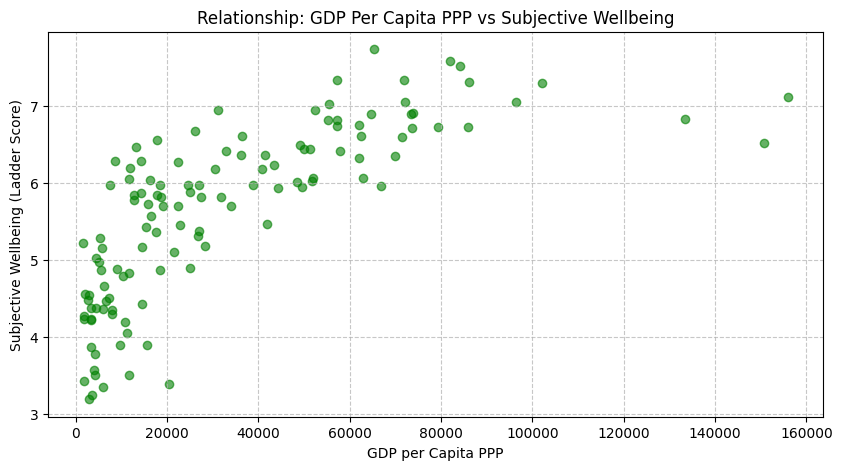

In [23]:
# PLotting all countries on a scatter plot to show the relationship b/w wealth and subjective wellbeing
plt.figure(figsize=(10, 5))
plt.scatter(df['GDP'], df['Ladder score'], alpha=0.6, color='green')
plt.title('Relationship: GDP Per Capita PPP vs Subjective Wellbeing')
plt.xlabel('GDP per Capita PPP')
plt.ylabel('Subjective Wellbeing (Ladder Score)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

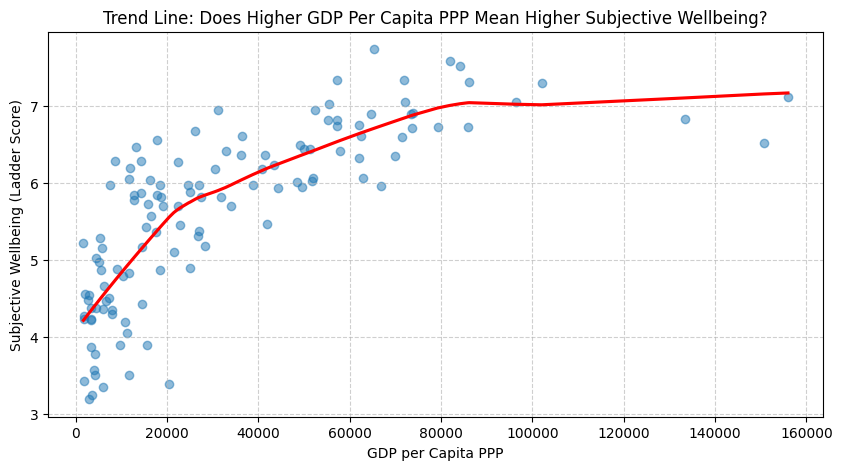

In [24]:
plt.figure(figsize=(10, 5))

sns.regplot(data=df, x='GDP', y='Ladder score', lowess=True, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}
           )

plt.title('Trend Line: Does Higher GDP Per Capita PPP Mean Higher Subjective Wellbeing?')
plt.xlabel('GDP per Capita PPP')
plt.ylabel('Subjective Wellbeing (Ladder Score)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
rich_countries = df[df['GDP']>40000] # filtering for wealthy countries
outlier_check = rich_countries[rich_countries['Ladder score']>7.0] # filtering for the rich and largely satisfied countries
outlier_check[['Country name', 'Ladder score', 'GDP']] 

,Country name,Ladder score,GDP
0,FINLAND,7.741,65378.38419
1,DENMARK,7.583,81878.23498
2,ICELAND,7.525,84256.84546
3,SWEDEN,7.344,71844.91299
4,ISRAEL,7.341,57235.77632
5,NETHERLANDS,7.319,86173.62908
6,NORWAY,7.302,102037.52680
7,LUXEMBOURG,7.122,155941.28820
8,SWITZERLAND,7.060,96497.69480
9,AUSTRALIA,7.057,72111.18446


In [26]:
# Plotting the rich and largely satisfied countries on a plot to look for outliers

import plotly.express as px

fig = px.scatter(
    outlier_check,
    x='GDP',
    y='Ladder score',
    text='Country name'
)

fig.update_traces(textposition='bottom center')
fig.show()